In [1]:
# ==========================================================
# Handwritten Formula Recognition
# Cell 1 - Imports
# ==========================================================

import os
import json
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torchvision import transforms
from torchvision.models import efficientnet_b0

warnings.filterwarnings("ignore")

In [2]:
# ==========================================================
# Cell 2 - Configuration
# ==========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
torch.backends.cudnn.benchmark = True

print("=" * 60)
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
print("Device  :", DEVICE)

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))
    print("VRAM    :",
          round(torch.cuda.get_device_properties(0).total_memory/1024**3,2),
          "GB")

print("=" * 60)

PyTorch : 2.11.0+cu128
CUDA    : True
Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM    : 6.0 GB


In [3]:
# ==========================================================
# Cell 4 - Hyperparameters
# ==========================================================

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 512
BATCH_SIZE = 48

NUM_WORKERS = 0

EPOCHS = 50

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

EMBED_DIM = 256

NUM_HEADS = 8

NUM_LAYERS = 4

DROPOUT = 0.1

MAX_FORMULA_LENGTH = 128

SAVE_EVERY = 10

PATIENCE = 10

In [5]:
# ==========================================================
# Cell 9 - Vocabulary
# ==========================================================

from collections import Counter


class Vocabulary:

    def __init__(self, min_freq=1):

        self.min_freq = min_freq

        self.special_tokens = [
            "<PAD>",
            "<SOS>",
            "<EOS>",
            "<UNK>"
        ]

        self.token2idx = {}
        self.idx2token = {}

    def build(self, formulas):

        counter = Counter()

        for formula in formulas:

            tokens = formula.split()

            counter.update(tokens)

        vocab_tokens = [
            token
            for token, freq in counter.items()
            if freq >= self.min_freq
        ]

        all_tokens = self.special_tokens + sorted(vocab_tokens)

        self.token2idx = {
            token: idx
            for idx, token in enumerate(all_tokens)
        }

        self.idx2token = {
            idx: token
            for token, idx in self.token2idx.items()
        }

    def encode(self, formula):

        tokens = formula.split()

        encoded = [
            self.token2idx["<SOS>"]
        ]

        for token in tokens:

            encoded.append(
                self.token2idx.get(
                    token,
                    self.token2idx["<UNK>"]
                )
            )

        encoded.append(
            self.token2idx["<EOS>"]
        )

        return encoded

    def decode(self, indices):

        tokens = []

        for idx in indices:

            token = self.idx2token.get(
                idx,
                "<UNK>"
            )

            if token == "<EOS>":
                break

            if token not in [
                "<SOS>",
                "<PAD>"
            ]:
                tokens.append(token)

        return " ".join(tokens)

    def __len__(self):

        return len(self.token2idx)

In [6]:
# ==========================================================
# Cell 3 - Load Vocabulary
# ==========================================================

import pickle

# Load vocabulary
with open("weights/vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

# Vocabulary information
print("=" * 60)
print("Vocabulary Loaded Successfully!")
print(f"Vocabulary Size : {len(vocab)}")
print(f"PAD Token       : {vocab.token2idx['<PAD>']}")
print(f"SOS Token       : {vocab.token2idx['<SOS>']}")
print(f"EOS Token       : {vocab.token2idx['<EOS>']}")
print("=" * 60)

# Special token indices
PAD_IDX = vocab.token2idx["<PAD>"]
SOS_IDX = vocab.token2idx["<SOS>"]
EOS_IDX = vocab.token2idx["<EOS>"]

Vocabulary Loaded Successfully!
Vocabulary Size : 241
PAD Token       : 0
SOS Token       : 1
EOS Token       : 2


In [7]:
# ==========================================================
# Cell 20 - Positional Encoding
# ==========================================================

import math
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, dropout=0.1, max_len=5000):

        super().__init__()

        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(max_len).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)        # (1, max_len, d_model)

        self.register_buffer("pe", pe)

    def forward(self, x):

        x = x + self.pe[:, :x.size(1)]

        return self.dropout(x)

In [8]:
# ==========================================================
# Encoder
# ==========================================================

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class Encoder(nn.Module):

    def __init__(self):

        super().__init__()

        backbone = efficientnet_b0(
            weights=EfficientNet_B0_Weights.DEFAULT
        )

        self.features = backbone.features

        self.pool = nn.AdaptiveAvgPool2d((4, 16))

        self.projection = nn.Conv2d(
            1280,
            EMBED_DIM,
            kernel_size=1
        )

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = self.projection(x)

        B, C, H, W = x.shape

        x = x.flatten(2)      # (B, C, 64)

        x = x.transpose(1, 2) # (B, 64, C)

        return x

In [9]:
# ==========================================================
# Transformer Decoder
# ==========================================================

class Decoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Embedding(
            len(vocab),
            EMBED_DIM,
            padding_idx=PAD_IDX
        )

        self.position = PositionalEncoding(
            EMBED_DIM,
            DROPOUT
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=EMBED_DIM,
            nhead=NUM_HEADS,
            dim_feedforward=1024,
            dropout=DROPOUT,
            batch_first=True
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=NUM_LAYERS
        )

        self.fc = nn.Linear(
            EMBED_DIM,
            len(vocab)
        )

    def forward(
        self,
        memory,
        tgt,
        tgt_mask=None,
        tgt_padding_mask=None
    ):

        tgt = self.embedding(tgt)

        tgt = self.position(tgt)

        out = self.decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_padding_mask
        )

        out = self.fc(out)

        return out

In [10]:
# ==========================================================
# Formula Recognizer
# ==========================================================

class FormulaRecognizer(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = Encoder()

        self.decoder = Decoder()

    def forward(
        self,
        images,
        tgt,
        tgt_mask=None,
        tgt_padding_mask=None
    ):

        memory = self.encoder(images)

        return self.decoder(
            memory,
            tgt,
            tgt_mask,
            tgt_padding_mask
        )

In [11]:
# ==========================================================
# Load Best Model (PyTorch 2.6+ Compatible)
# ==========================================================

import torch

best_model = FormulaRecognizer().to(DEVICE)

checkpoint = torch.load(
    "checkpoints/best_model.pth",
    map_location=DEVICE,
    weights_only=False      # Required because checkpoint contains Vocabulary object
)

# Print checkpoint contents
print("Checkpoint Keys:")
print(checkpoint.keys())

# Load model weights
best_model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_model.eval()

print("\n" + "="*60)
print("✅ Best Model Loaded Successfully!")
print("Epoch          :", checkpoint["epoch"] + 1)
print("Best Val Loss  :", checkpoint["best_val_loss"])
print("Device         :", next(best_model.parameters()).device)
print("="*60)

Checkpoint Keys:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_val_loss', 'vocab'])

✅ Best Model Loaded Successfully!
Epoch          : 42
Best Val Loss  : 0.2293324842571448
Device         : cuda:0


In [30]:
# ==========================================================
# Cell 10 - Image Preprocessing
# ==========================================================

from PIL import Image

# Same function used during training
def resize_with_padding(image, target_size=(512, 128)):

    target_w, target_h = target_size

    w, h = image.size

    scale = min(target_w / w, target_h / h)

    new_w = int(w * scale)
    new_h = int(h * scale)

    image = image.resize(
        (new_w, new_h),
        Image.Resampling.LANCZOS
    )

    canvas = Image.new(
        "RGB",
        (target_w, target_h),
        (255, 255, 255)
    )

    left = (target_w - new_w) // 2
    top = (target_h - new_h) // 2

    canvas.paste(image, (left, top))

    return canvas


predict_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])


def preprocess_image(image_path):

    image = Image.open(image_path).convert("RGB")

    # SAME preprocessing as training
    image = resize_with_padding(
        image,
        (IMAGE_WIDTH, IMAGE_HEIGHT)
    )

    original_image = image.copy()

    image = predict_transform(image)

    image = image.unsqueeze(0)

    return original_image, image.to(DEVICE)

In [45]:
# ==========================================================
# Create Causal Mask
# ==========================================================

def create_causal_mask(seq_len):

    mask = torch.triu(
        torch.ones(seq_len, seq_len, device=DEVICE),
        diagonal=1
    )

    mask = mask.masked_fill(
        mask == 1,
        float("-inf")
    )

    return mask

In [46]:
# ==========================================================
# Cell 11 - Beam Search Decoder
# ==========================================================

import torch
import torch.nn.functional as F

@torch.no_grad()
def beam_search_decode(
    model,
    image_tensor,
    beam_size=5,
    max_length=MAX_FORMULA_LENGTH,
    length_penalty=0.7
):

    model.eval()

    memory = model.encoder(image_tensor)

    # (sequence, score)
    beams = [
        (
            torch.tensor([[SOS_IDX]], device=DEVICE),
            0.0
        )
    ]

    completed = []

    for _ in range(max_length):

        candidates = []

        for seq, score in beams:

            # Finished sequence
            if seq[0, -1].item() == EOS_IDX:
                completed.append((seq, score))
                continue

            tgt_mask = create_causal_mask(seq.size(1))

            tgt_padding_mask = (seq == PAD_IDX)

            output = model.decoder(
                memory=memory,
                tgt=seq,
                tgt_mask=tgt_mask,
                tgt_padding_mask=tgt_padding_mask
            )

            logits = output[:, -1, :]

            log_probs = F.log_softmax(logits, dim=-1)

            values, indices = torch.topk(
                log_probs,
                beam_size,
                dim=-1
            )

            for k in range(beam_size):

                token = indices[0, k].view(1, 1)

                new_seq = torch.cat(
                    [seq, token],
                    dim=1
                )

                new_score = score + values[0, k].item()

                candidates.append(
                    (new_seq, new_score)
                )

        if len(candidates) == 0:
            break

        # Normalize by length
        candidates = sorted(
            candidates,
            key=lambda x: x[1] / ((x[0].size(1)) ** length_penalty),
            reverse=True
        )

        beams = candidates[:beam_size]

    if completed:
        best_seq = max(
            completed,
            key=lambda x: x[1] / ((x[0].size(1)) ** length_penalty)
        )[0]
    else:
        best_seq = beams[0][0]

    tokens = []

    for idx in best_seq.squeeze().tolist():

        if idx in [SOS_IDX, PAD_IDX]:
            continue

        if idx == EOS_IDX:
            break

        tokens.append(vocab.idx2token[idx])

    return " ".join(tokens)

In [48]:
# ==========================================================
# Cell 12 - Predict Function
# ==========================================================

def predict(image_path):

    original_image, image_tensor = preprocess_image(image_path)

    prediction = beam_search_decode(
        best_model,
        image_tensor,
        beam_size=8
    )

    return original_image, prediction

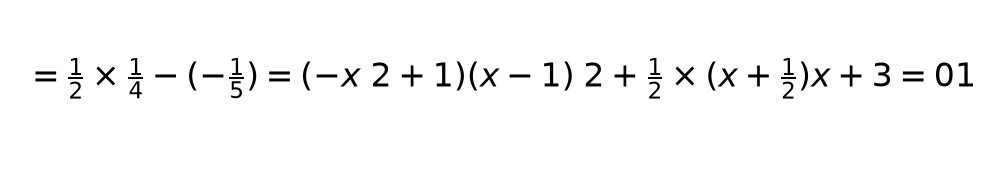

In [49]:
# ==========================================================
# Render Predicted LaTeX
# ==========================================================

import matplotlib.pyplot as plt

latex = prediction

plt.figure(figsize=(10, 2))
plt.axis("off")

plt.text(
    0.02,
    0.5,
    f"${latex}$",
    fontsize=24
)

plt.show()

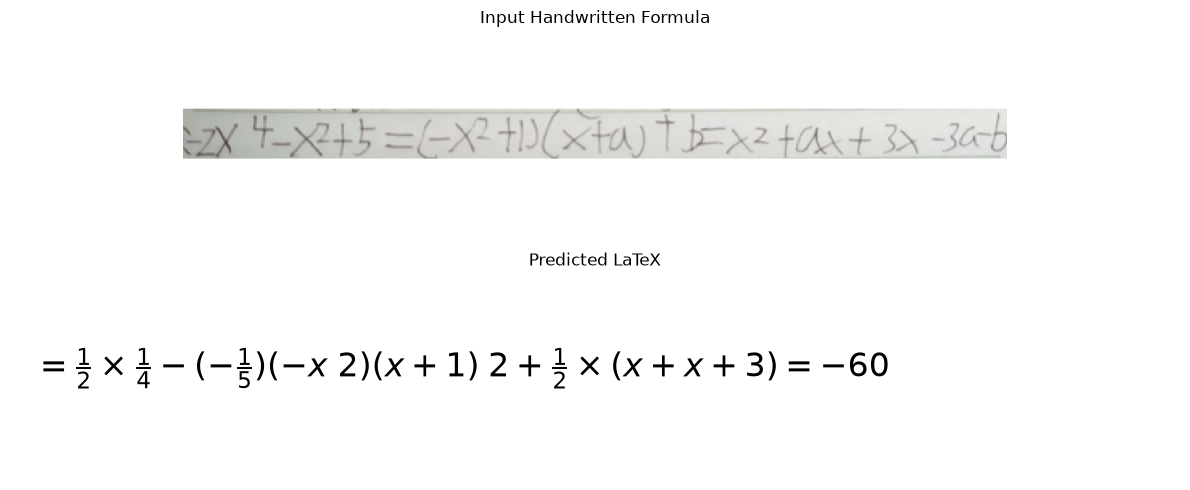

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(12, 5))

# Original image
ax[0].imshow(original_image)
ax[0].axis("off")
ax[0].set_title("Input Handwritten Formula")

# Rendered prediction
ax[1].axis("off")
ax[1].text(
    0.02,
    0.5,
    f"${prediction}$",
    fontsize=24
)
ax[1].set_title("Predicted LaTeX")

plt.tight_layout()
plt.show()

In [44]:
# ==========================================================
# Cell 13 - Test on One Image
# ==========================================================

# Change this to your image path
IMAGE_PATH = "dataset/HME100K/test/test_images/test_3.jpg"

# Predict
original_image, prediction = predict(IMAGE_PATH)

print("=" * 70)
print("Prediction")
print("=" * 70)
print(prediction)
print("=" * 70)

Prediction
= \frac { 1 } { 2 } \times \frac { 1 } { 4 } - ( - \frac { 1 } { 5 } ) = ( - x ^ { 2 } + 1 ) ( x - 1 ) ^ { 2 } + \frac { 1 } { 2 } \times ( x + \frac { 1 } { 2 } ) x + 3 = 0 1
